In [40]:
import sys
import os
sys.path.append(os.path.abspath('..'))

from data.pull_data import pull_lobster_data

import pandas as pd
import numpy as np

VOL_THRESHOLD = 5
VOL_TARGET = 0.15
SECONDS_PER_MINUTE = 60
SECONDS_PER_HOUR = 3600
SECONDS_PER_DAY = 23400
SECONDS_PER_YEAR = SECONDS_PER_DAY * 252
HALFLIFE_WINSORISE = SECONDS_PER_DAY * 60

from typing import List, Tuple

In [41]:
def calc_returns(srs: pd.Series, offset: int = 1) -> pd.Series:
    """Calculates returns over the specified number of seconds."""
    return srs / srs.shift(offset) - 1.0

def calc_vol(returns: pd.Series, span: int = 300) -> pd.Series:
    """Calculates exponentially weighted volatility over given span (default ~5 minutes)."""
    return (
        returns.ewm(span=span, min_periods=span)
        .std()
        .bfill()
    )

def calc_vol_scaled_returns(returns: pd.Series, vol: pd.Series = pd.Series(dtype=float)) -> pd.Series:
    """Scales returns to target volatility using annualised volatility."""
    annualised_vol = vol * np.sqrt(SECONDS_PER_YEAR)
    return returns * VOL_TARGET / annualised_vol.shift(1)

class MACDStrategy:
    def __init__(self, trend_combinations: List[Tuple[float, float]] = None):
        if trend_combinations is None:
            self.trend_combinations = [
                (300, 900),  # 5 min vs 15 min
                (600, 1800),  # 10 min vs 30 min
                (1800, 7200),  # 30 min vs 2 hours
                (3600, 14400),  # 1 hr vs 4 hrs
                (7200, 28800),  # 2 hrs vs 8 hrs
                (14400, 86400)  # 4 hrs vs 24 hrs
            ]
        else:
            self.trend_combinations = trend_combinations

    @staticmethod
    def calc_signal(srs: pd.Series, short_timescale: int, long_timescale: int) -> float:
        def _calc_halflife(timescale):
            return np.log(0.5) / np.log(1 - 1 / timescale)

        short_ema = srs.ewm(halflife=_calc_halflife(short_timescale)).mean()
        long_ema = srs.ewm(halflife=_calc_halflife(long_timescale)).mean()
        macd = short_ema - long_ema

        # Rolling std over e.g. 4 hours
        window_seconds = 14_400
        rolling_std = srs.rolling(window_seconds).std().bfill()

        # Annualisation factor
        SECONDS_PER_YEAR = 252 * 23_400
        annualisation_factor = np.sqrt(SECONDS_PER_YEAR / window_seconds)

        q = macd / rolling_std
        q = q * annualisation_factor

        return q

    @staticmethod
    def scale_signal(y):
        return y * np.exp(-(y ** 2) / 4) / 0.89

    def calc_combined_signal(self, srs: pd.Series) -> float:
        return np.sum(
            [self.calc_signal(srs, S, L) for S, L in self.trend_combinations]
        ) / len(self.trend_combinations)


In [42]:
def deep_momentum_strategy_features(df: pd.DataFrame, trend_combinations: List[Tuple[float, float]] = None) -> pd.DataFrame:
    """
    
    """
    df = df.copy()

    df = df[
        ~df['mid_price'].isna()
        | ~df['mid_price'].isnull()
        | (df['mid_price'] > 1e-8)  # price is zero
    ].copy()

    # winsorize using rolling 5X standard deviations to remove extreme outliers
    df['srs'] = df['mid_price']
    ewm = df['srs'].ewm(halflife=HALFLIFE_WINSORISE) # TODO: decide on halflife when frequency is 's'
    avgs = ewm.mean()
    stds = ewm.std()
    lower_bound = avgs - VOL_THRESHOLD * stds
    upper_bound = avgs + VOL_THRESHOLD * stds
    df['srs'] = np.clip(df['srs'], lower_bound, upper_bound)

    # Apply functions to your DataFrame
    df['second_returns'] = calc_returns(df['srs'], offset=1)
    df['second_vol'] = calc_vol(df['second_returns'])
    df['target_returns'] = calc_vol_scaled_returns(df['second_returns'], df['second_vol']).shift(-1)

    # Normalised returns for different time windows
    def calc_normalised_returns(offset_seconds: int) -> pd.Series:  # docstring left as is
        returns = calc_returns(df['srs'], offset=offset_seconds)
        return returns / df['second_vol'] / np.sqrt(offset_seconds)

    # Add normalised return columns
    df['norm_second_return'] = calc_normalised_returns(1)
    df['norm_minute_return'] = calc_normalised_returns(SECONDS_PER_MINUTE)
    df['norm_hour_return'] = calc_normalised_returns(SECONDS_PER_HOUR)
    df['norm_day_return'] = calc_normalised_returns(SECONDS_PER_DAY)
    df['norm_week_return'] = calc_normalised_returns(SECONDS_PER_DAY * 5)
    df['norm_month_return'] = calc_normalised_returns(SECONDS_PER_DAY * 21)
    df['norm_quarter_return'] = calc_normalised_returns(SECONDS_PER_DAY * 63)
    # df['norm_annual_return'] = calc_normalised_returns(SECONDS_PER_DAY * 252)

    for short_window, long_window in trend_combinations:
        df[f'macd_{short_window}_{long_window}'] = MACDStrategy.calc_signal(
            df['srs'], short_window, long_window
        )

    if len(df):
        df['hour_of_day'] = df.index.hour 
        df['minute_of_hour'] = df.index.minute 
        df['second_of_minute'] = df.index.second 
        df['day_of_week'] = df.index.dayofweek
        df['day_of_month'] = df.index.day
        df['week_of_year'] = df.index.isocalendar().week
        df['month_of_year'] = df.index.month
        df['year'] = df.index.year
        df['date'] = df.index  # duplication but sometimes makes life easier
    else:
        df['hour_of_day'] = []
        df['minute_of_hour'] = []
        df['second_of_minute'] = []
        df['day_of_week'] = []
        df['day_of_month'] = []
        df['week_of_year'] = []
        df['month_of_year'] = []
        df['year'] = []
        df['date'] = []

    return df.dropna()

In [46]:
trend_combinations = [
    (300, 900),  # 5 min vs 15 min
    (600, 1800),  # 10 min vs 30 min
    (1800, 7200),  # 30 min vs 2 hours
    (3600, 14400),  # 1 hr vs 4 hrs
    (7200, 28800),  # 2 hrs vs 8 hrs
    (14400, 86400)  # 4 hrs vs 24 hrs
]

df = deep_momentum_strategy_features(pull_lobster_data('AAPL'), trend_combinations)

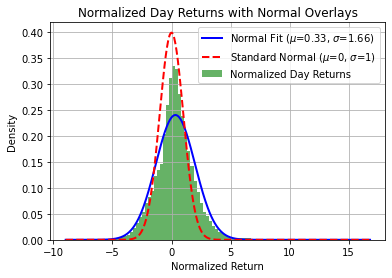

In [50]:
from scipy.stats import norm

import matplotlib.pyplot as plt

# Plot histogram
ax = df['norm_day_return'].hist(
    bins=100, 
    density=True,
    alpha=0.6, 
    color='g', 
    label='Normalized Day Returns'
)

x_pos = np.linspace(df['norm_day_return'].min(), df['norm_day_return'].max(), num=500)

# Fit normal distribution to the data
mu, std = df['norm_day_return'].mean(), df['norm_day_return'].std()
pdf = norm.pdf(x_pos, mu, std)
plt.plot(x_pos, pdf, 'b-', lw=2, label=f'Normal Fit ($\mu$={mu:.2f}, $\sigma$={std:.2f})')

# Overlay standard normal distribution
plt.plot(x_pos, norm.pdf(x_pos, 0, 1), 'r--', lw=2, label='Standard Normal ($\mu$=0, $\sigma$=1)')

plt.legend()
plt.title('Normalized Day Returns with Normal Overlays')
plt.xlabel('Normalized Return')
plt.ylabel('Density')
plt.show()

In [ ]:
features = pd.concat(
        [
            deep_momentum_strategy_features(pull_quandl_sample_data(ticker)).assign(
                ticker=ticker
            )
            for ticker in tickers
        ]
    )

In [ ]:


def main(
    tickers: List[str],
    cpd_module_folder: str,
    lookback_window_length: int,
    output_file_path: str,
    extra_lbw: List[int],
):
    features = pd.concat(
        [
            deep_momentum_strategy_features(pull_quandl_sample_data(ticker)).assign(
                ticker=ticker
            )
            for ticker in tickers
        ]
    )

    features.date = features.index
    features.index.name = "Date"

    if lookback_window_length:
        features_w_cpd = include_changepoint_features(
            features, cpd_module_folder, lookback_window_length
        )

        if extra_lbw:
            for extra in extra_lbw:
                extra_data = pd.read_csv(
                    output_file_path.replace(
                        f"quandl_cpd_{lookback_window_length}lbw.csv",
                        f"quandl_cpd_{extra}lbw.csv",
                    ),
                    index_col=0,
                    parse_dates=True,
                ).reset_index()[
                    ["date", "ticker", f"cp_rl_{extra}", f"cp_score_{extra}"]
                ]
                extra_data["date"] = pd.to_datetime(extra_data["date"])

                features_w_cpd = pd.merge(
                    features_w_cpd.set_index(["date", "ticker"]),
                    extra_data.set_index(["date", "ticker"]),
                    left_index=True,
                    right_index=True,
                ).reset_index()
                features_w_cpd.index = features_w_cpd["date"]
                features_w_cpd.index.name = "Date"
        else:
            features_w_cpd.index.name = "Date"
        features_w_cpd.to_csv(output_file_path)
    else:
        features.to_csv(output_file_path)


if __name__ == "__main__":

    def get_args():
        """Returns settings from command line."""

        parser = argparse.ArgumentParser(description="Run changepoint detection module")
        # parser.add_argument(
        #     "cpd_module_folder",
        #     metavar="c",
        #     type=str,
        #     nargs="?",
        #     default=CPD_QUANDL_OUTPUT_FOLDER_DEFAULT,
        #     # choices=[],
        #     help="Input folder for CPD outputs.",
        # )
        parser.add_argument(
            "lookback_window_length",
            metavar="l",
            type=int,
            nargs="?",
            default=None,
            # choices=[],
            help="Input folder for CPD outputs.",
        )
        # parser.add_argument(
        #     "output_file_path",
        #     metavar="f",
        #     type=str,
        #     nargs="?",
        #     default=FEATURES_QUANDL_FILE_PATH_DEFAULT,
        #     # choices=[],
        #     help="Output file location for csv.",
        # )
        parser.add_argument(
            "extra_lbw",
            metavar="-e",
            type=int,
            nargs="*",
            default=[],
            # choices=[],
            help="Fill missing prices.",
        )

        args = parser.parse_known_args()[0]

        return (
            QUANDL_TICKERS,
            CPD_QUANDL_OUTPUT_FOLDER(args.lookback_window_length),
            args.lookback_window_length,
            FEATURES_QUANDL_FILE_PATH(args.lookback_window_length),
            args.extra_lbw,
        )

    main(*get_args())
